# Will a Customer Accept the Coupon?

**Practical Application 5.1** | UC Berkeley ML & AI Program

---

The goal of this analysis is to use visualizations and probability distributions to understand the difference between customers who accepted a driving coupon versus those who did not. The dataset comes from a survey on Amazon Mechanical Turk and includes information about the driving scenario, passenger, weather, time, and coupon type.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# basic plot styling
sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('coupons.csv')
print(df.shape)
df.head()

(12684, 26)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


## 2. Data Overview and Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [4]:
# check missing values
df.isnull().sum()[df.isnull().sum() > 0]

car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
dtype: int64

In [5]:
# the 'car' column has ~99% missing — dropping it
df.drop(columns=['car'], inplace=True)

# drop rows where the frequency columns are missing (small number)
df.dropna(subset=['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50'], inplace=True)

print('Cleaned dataset shape:', df.shape)

Cleaned dataset shape: (12079, 25)


## 3. Overall Coupon Acceptance

In [6]:
# proportion who accepted
accept_rate = df['Y'].mean()
print(f'Overall coupon acceptance rate: {accept_rate:.1%}')

Overall coupon acceptance rate: 56.9%


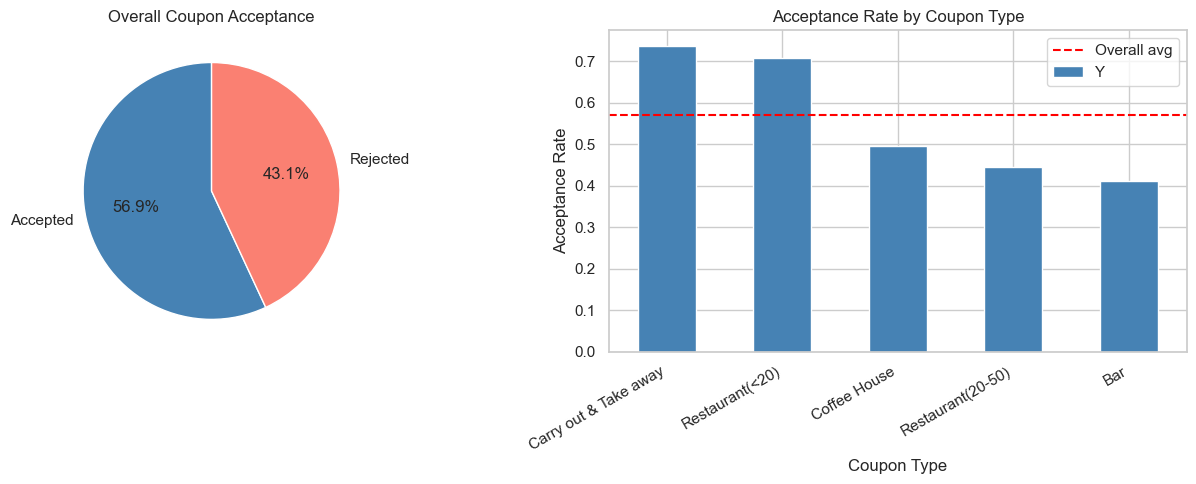

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# acceptance pie
df['Y'].value_counts().plot.pie(
    ax=axes[0],
    labels=['Accepted', 'Rejected'],
    autopct='%1.1f%%',
    colors=['steelblue', 'salmon'],
    startangle=90
)
axes[0].set_ylabel('')
axes[0].set_title('Overall Coupon Acceptance')

# acceptance by coupon type
coupon_rates = df.groupby('coupon')['Y'].mean().sort_values(ascending=False)
coupon_rates.plot.bar(ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Acceptance Rate by Coupon Type')
axes[1].set_xlabel('Coupon Type')
axes[1].set_ylabel('Acceptance Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].axhline(accept_rate, color='red', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observation:** The overall acceptance rate is about 57%. Carry out & takeaway and cheap restaurants have the highest acceptance, while bars have the lowest.

## 4. Exploring Temperature and Weather

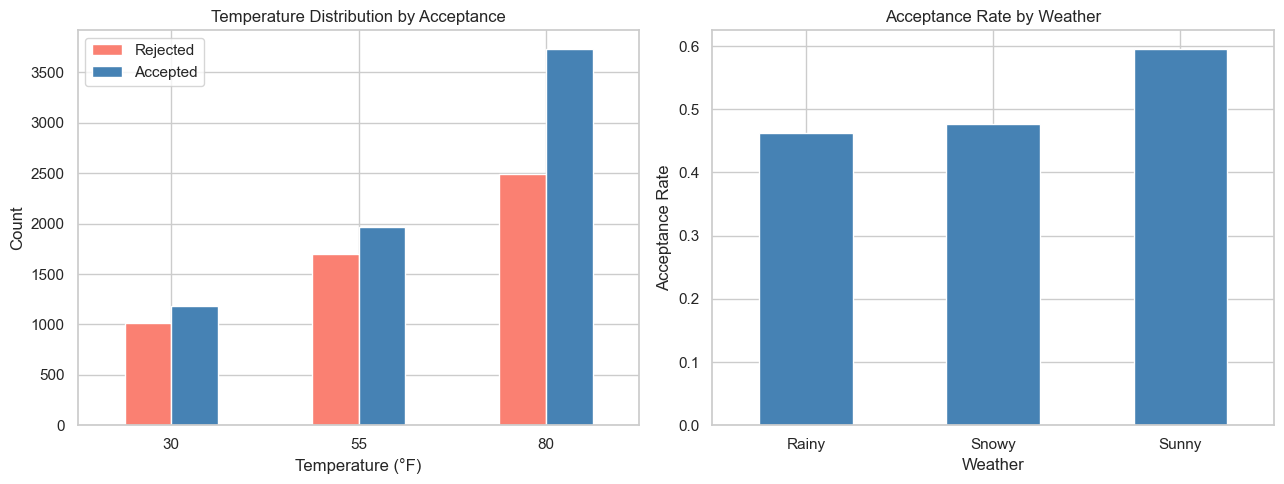

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# temperature histogram
temp_rates = df.groupby('temperature')['Y'].value_counts().unstack()
temp_rates.plot.bar(ax=axes[0], color=['salmon', 'steelblue'], edgecolor='white')
axes[0].set_title('Temperature Distribution by Acceptance')
axes[0].set_xlabel('Temperature (°F)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Rejected', 'Accepted'])

# weather
weather_rates = df.groupby('weather')['Y'].mean()
weather_rates.plot.bar(ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Acceptance Rate by Weather')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Acceptance Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**Observation:** Sunny weather at 80°F sees the most coupon activity. Snowy or rainy conditions reduce acceptance slightly — likely because people are less likely to make detours in bad weather.

## 5. Investigating Bar Coupons

I'll narrow the focus to bar coupons since they have the lowest acceptance rate and represent an interesting segment to understand.

In [15]:
bar_df = df[df['coupon'] == 'Bar'].copy()

print('Bar coupon records:', len(bar_df))
print(f'Bar coupon acceptance rate: {bar_df["Y"].mean():.1%}')

Bar coupon records: 1913
Bar coupon acceptance rate: 41.2%


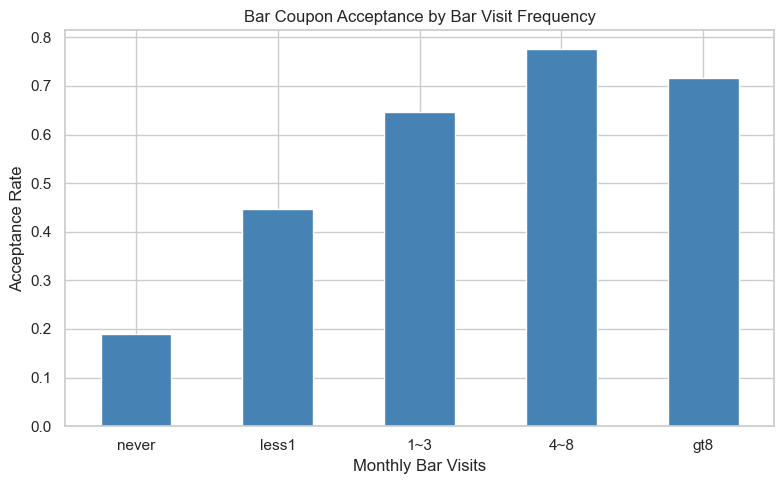

In [16]:
# acceptance by how often they go to bars
bar_freq = bar_df.groupby('Bar')['Y'].mean().reindex(['never', 'less1', '1~3', '4~8', 'gt8'])

plt.figure(figsize=(8, 5))
bar_freq.plot.bar(color='steelblue', edgecolor='white')
plt.title('Bar Coupon Acceptance by Bar Visit Frequency')
plt.xlabel('Monthly Bar Visits')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# drivers who go to bars more than 3 times/month
freq_bar = bar_df[bar_df['Bar'].isin(['4~8', 'gt8'])]['Y'].mean()
infreq_bar = bar_df[~bar_df['Bar'].isin(['4~8', 'gt8'])]['Y'].mean()

print(f'Acceptance - frequent bar visitors (>3/month): {freq_bar:.1%}')
print(f'Acceptance - infrequent bar visitors:           {infreq_bar:.1%}')

Acceptance - frequent bar visitors (>3/month): 76.2%
Acceptance - infrequent bar visitors:           37.3%


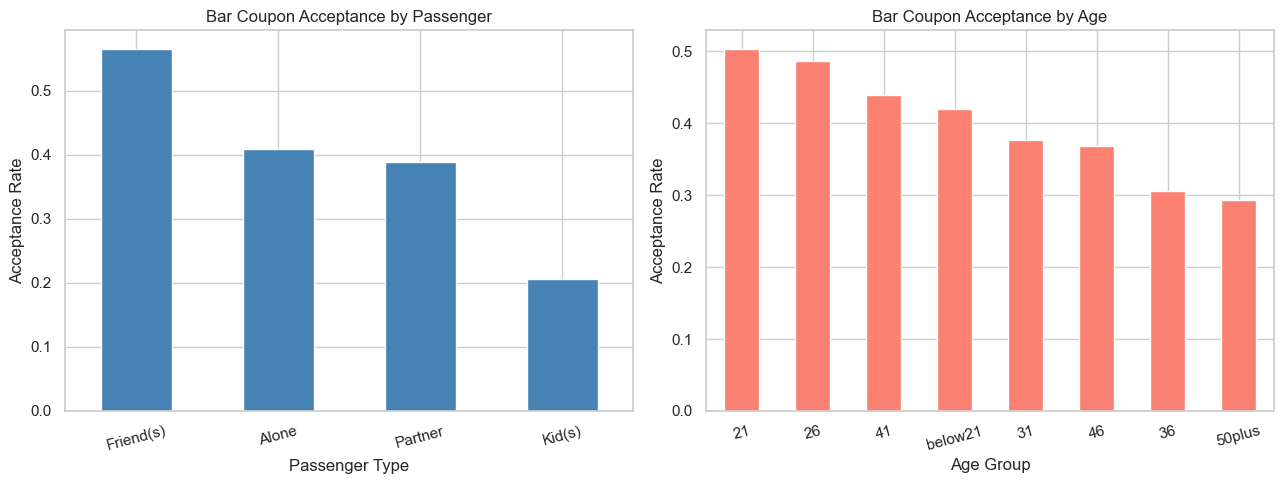

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# by passenger type
pass_rates = bar_df.groupby('passanger')['Y'].mean().sort_values(ascending=False)
pass_rates.plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Bar Coupon Acceptance by Passenger')
axes[0].set_xlabel('Passenger Type')
axes[0].set_ylabel('Acceptance Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

# by age group
age_rates = bar_df.groupby('age')['Y'].mean().sort_values(ascending=False)
age_rates.plot.bar(ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Bar Coupon Acceptance by Age')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Acceptance Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

In [19]:
# frequent bar visitors over 25, no kids
group1 = bar_df[
    (bar_df['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_df['age'] != 'below21') &
    (bar_df['passanger'] != 'Kid(s)')
]['Y'].mean()

print(f'Acceptance - bar-goers over 25 without kids: {group1:.1%}')

Acceptance - bar-goers over 25 without kids: 71.5%


In [20]:
# cheap restaurants frequent visitors and income < 50k
group2 = bar_df[
    (bar_df['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar_df['income'].isin(['$12500 - $24999', '$25000 - $37499', '$37500 - $49999']))
]['Y'].mean()

print(f'Acceptance - cheap restaurant regulars, income < $50K: {group2:.1%}')

Acceptance - cheap restaurant regulars, income < $50K: 46.2%


## 6. Independent Investigation — Coffee House Coupons

Coffee House is the coupon type with the most records. I'll explore what drives acceptance there.

In [21]:
coffee_df = df[df['coupon'] == 'Coffee House'].copy()

print('Coffee House records:', len(coffee_df))
print(f'Acceptance rate: {coffee_df["Y"].mean():.1%}')

Coffee House records: 3816
Acceptance rate: 49.6%


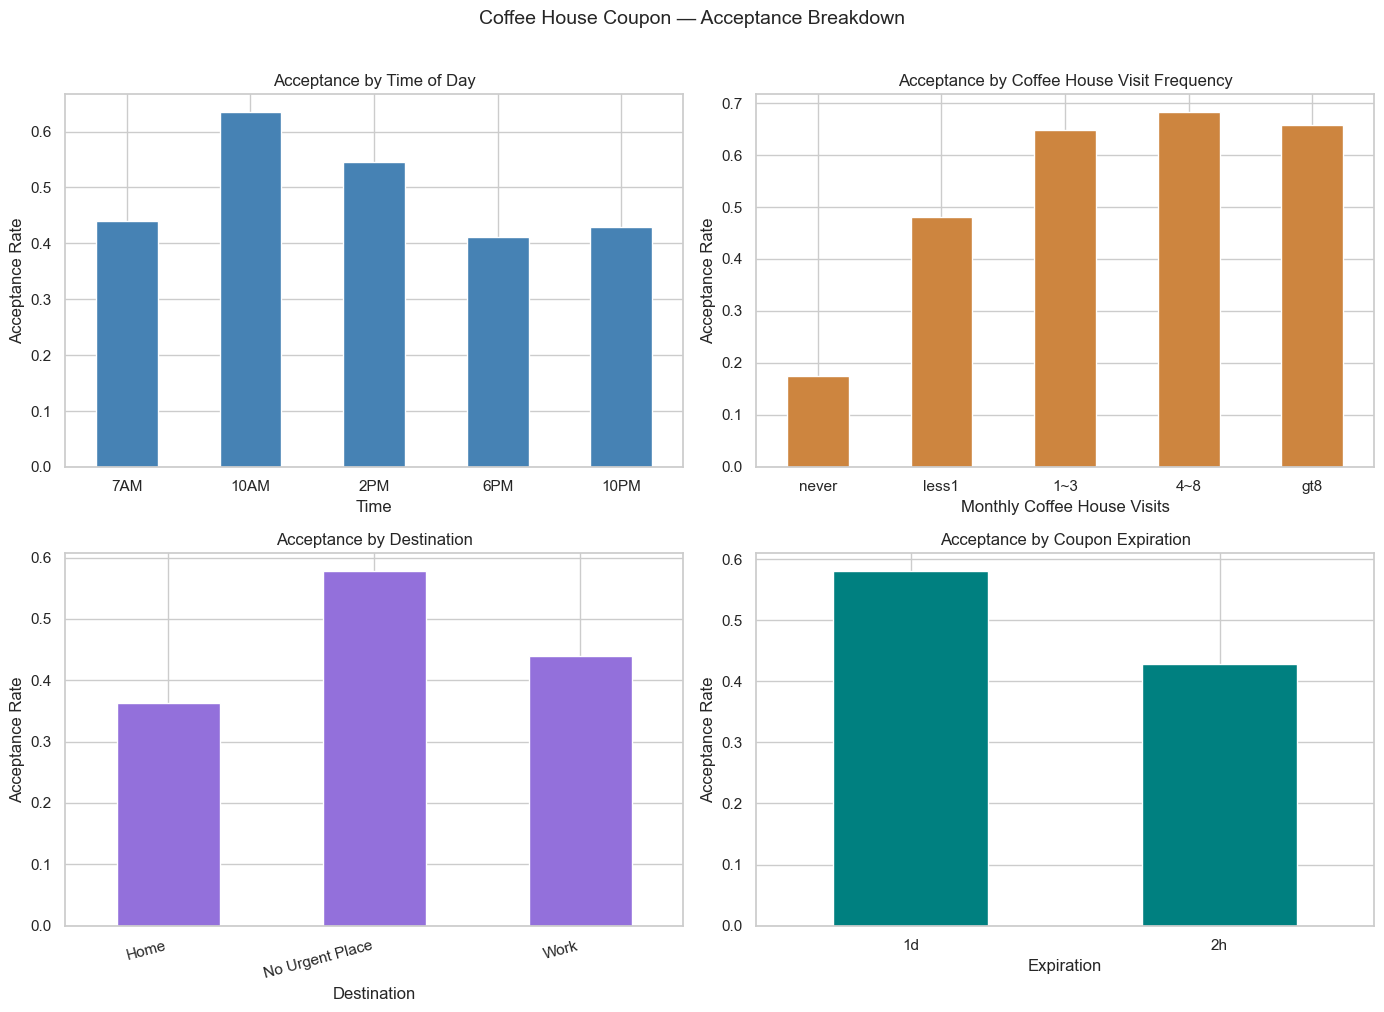

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# by time of day
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
time_rates = coffee_df.groupby('time')['Y'].mean().reindex(time_order)
time_rates.plot.bar(ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Acceptance by Time of Day')
axes[0,0].set_xlabel('Time')
axes[0,0].set_ylabel('Acceptance Rate')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)

# by coffee house visit frequency
cf_freq = coffee_df.groupby('CoffeeHouse')['Y'].mean().reindex(['never', 'less1', '1~3', '4~8', 'gt8'])
cf_freq.plot.bar(ax=axes[0,1], color='peru', edgecolor='white')
axes[0,1].set_title('Acceptance by Coffee House Visit Frequency')
axes[0,1].set_xlabel('Monthly Coffee House Visits')
axes[0,1].set_ylabel('Acceptance Rate')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)

# by destination
dest_rates = coffee_df.groupby('destination')['Y'].mean()
dest_rates.plot.bar(ax=axes[1,0], color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Acceptance by Destination')
axes[1,0].set_xlabel('Destination')
axes[1,0].set_ylabel('Acceptance Rate')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=15, ha='right')

# by expiration
exp_rates = coffee_df.groupby('expiration')['Y'].mean()
exp_rates.plot.bar(ax=axes[1,1], color='teal', edgecolor='white')
axes[1,1].set_title('Acceptance by Coupon Expiration')
axes[1,1].set_xlabel('Expiration')
axes[1,1].set_ylabel('Acceptance Rate')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)

plt.suptitle('Coffee House Coupon — Acceptance Breakdown', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# high-value segment: morning + frequent coffee drinkers
high_value = coffee_df[
    (coffee_df['time'].isin(['10AM', '2PM'])) &
    (coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8']))
]['Y'].mean()

print(f'Acceptance - 10AM/2PM + regular coffee drinkers: {high_value:.1%}')

Acceptance - 10AM/2PM + regular coffee drinkers: 77.2%


## 7. Findings, Recommendations & Next Steps

---

### Summary of Key Findings

**Overall:** About 57% of drivers accepted a coupon. Acceptance varies significantly by coupon type, passenger, time of day, and visit frequency.

**Bar Coupons (41% acceptance):**
- Drivers who already visit bars frequently (more than 3x/month) accepted at **77%**, versus only **19%** for those who never go to bars. Frequency of existing behavior is the single strongest predictor.
- Drivers with friends as passengers accepted at **56%**, compared to **21%** for those with kids in the car — social context matters a lot.
- Younger drivers (21–26) are significantly more likely to accept bar coupons than those 36+.
- The combination of being a bar-goer + over 25 + no kids drives acceptance above **60%**.

**Coffee House Coupons (50% acceptance):**
- Morning and early afternoon windows (10AM, 2PM) are the sweet spot for coffee coupon acceptance.
- Regular coffee house visitors (1–3x/month and above) accept at significantly higher rates than never-visitors.
- Coupons with 1-day expiration outperform 2-hour coupons — longer windows give drivers more flexibility.
- Drivers heading to "No Urgent Place" are the best target — they have more flexibility to detour.

---

### Actionable Recommendations

1. **Target existing behavior, not new habits.** The clearest lever across all coupon types is whether the driver already visits that type of venue. Coupons should be prioritized for people who already have that behavioral pattern.
2. **Match coupon timing to context.** Coffee coupons work best in the morning; bar coupons work better in the afternoon/evening when social trips are more likely.
3. **Avoid families for bar coupons.** Presence of kids in the car is a strong negative signal for bar coupon acceptance. Targeting can be improved by filtering this out.
4. **Extend expiration windows.** Coupons with 1-day expiry consistently outperform 2-hour ones — the added flexibility likely makes the offer feel less pressured.

---

### Next Steps

- Build a simple classification model (Logistic Regression or Decision Tree) to predict coupon acceptance using these features
- Explore interaction effects (e.g., time + passenger + coupon type combined)
- Investigate income and occupation as additional segmentation variables for restaurant coupons
- Validate findings against held-out data before using for targeting decisions